# O1 rotating-selection analytics

This notebook validates the 70 adaptive runs, explains both depth-selection stages, and compares the adaptive policy with fixed depths 5, 10, 15, and 20 from `09_big_experiment`. Comparisons are matched by benchmark seed and SMAC seed.

In [31]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

RELATIVE_HERE = Path('experiments/synthaticBench/o1_deterministic/depth_policies/09_03_selection_rotating')
HERE = RELATIVE_HERE if RELATIVE_HERE.exists() else Path.cwd()
BIG_EXPERIMENT = HERE.parent / '09_big_experiment'
ROTATING_OUTPUT = HERE / 'smac_output'
FIXED_OUTPUT = BIG_EXPERIMENT / 'smac_output' / 'fixed'
CANDIDATE_DEPTHS = (5, 10, 15, 20)
BENCHMARK_SEEDS = tuple(range(40, 47))
SMAC_SEEDS = tuple(range(10))
N_TRIALS = 1000
CHECKPOINTS = (250, 300, 500, 750, 1000)
ORIGINAL_LABEL = 'Adaptive rotating'
FORCE20_LABEL = 'Rotating gap + forced depth 20'
ADAPTIVE_LABELS = (ORIGINAL_LABEL, FORCE20_LABEL)

print('Adaptive output:', ROTATING_OUTPUT.resolve())
print('Fixed controls:', FIXED_OUTPUT.resolve())

Adaptive output: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/09_03_selection_rotating/smac_output
Fixed controls: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/09_big_experiment/smac_output/fixed


## Load and validate trajectories

A trajectory is accepted only when its metadata and all 1,000 best-regret values are complete.

In [32]:
def read_json(path):
    with path.open() as handle:
        return json.load(handle)


def validate_common(data, path, benchmark_seed, smac_seed):
    errors = []
    if data.get('benchmark_seed') != benchmark_seed:
        errors.append('benchmark_seed')
    if data.get('smac_seed') != smac_seed:
        errors.append('smac_seed')
    if data.get('n_trials') != N_TRIALS:
        errors.append('n_trials')
    if len(data.get('best_regret', [])) != N_TRIALS:
        errors.append('best_regret length')
    if errors:
        raise ValueError(f'{path}: invalid {errors}')


adaptive = {}
missing_adaptive = []
for benchmark_seed in BENCHMARK_SEEDS:
    for smac_seed in SMAC_SEEDS:
        path = (ROTATING_OUTPUT / f'benchmark_seed_{benchmark_seed}' /
                'selection_rotating_5_10_15_20' / str(smac_seed) / 'trajectory.json')
        if not path.exists():
            missing_adaptive.append((benchmark_seed, smac_seed))
            continue
        data = read_json(path)
        validate_common(data, path, benchmark_seed, smac_seed)
        if data.get('selected_depth') not in CANDIDATE_DEPTHS:
            raise ValueError(f'{path}: invalid selected_depth')
        if len(data.get('selected_two', [])) != 2:
            raise ValueError(f'{path}: invalid selected_two')
        adaptive[(benchmark_seed, smac_seed)] = data

force20 = {}
missing_force20 = []
for benchmark_seed in BENCHMARK_SEEDS:
    for smac_seed in SMAC_SEEDS:
        path = (ROTATING_OUTPUT / f'benchmark_seed_{benchmark_seed}' /
                'selection_rotating_delay_rotation_force20' / str(smac_seed) / 'trajectory.json')
        if not path.exists():
            missing_force20.append((benchmark_seed, smac_seed))
            continue
        data = read_json(path)
        validate_common(data, path, benchmark_seed, smac_seed)
        if data.get('selected_depth') != 20:
            raise ValueError(f'{path}: forced policy did not select depth 20')
        if len(data.get('selected_two', [])) != 2:
            raise ValueError(f'{path}: invalid selected_two')
        force20[(benchmark_seed, smac_seed)] = data

fixed = {}
missing_fixed = []
for depth in CANDIDATE_DEPTHS:
    for benchmark_seed in BENCHMARK_SEEDS:
        for smac_seed in SMAC_SEEDS:
            path = (FIXED_OUTPUT / f'benchmark_seed_{benchmark_seed}' / f'fixed_depth_{depth}' /
                    str(smac_seed) / 'trajectory.json')
            if not path.exists():
                missing_fixed.append((depth, benchmark_seed, smac_seed))
                continue
            data = read_json(path)
            validate_common(data, path, benchmark_seed, smac_seed)
            fixed[(depth, benchmark_seed, smac_seed)] = data

coverage = pd.DataFrame({
    'collection': [ORIGINAL_LABEL, FORCE20_LABEL, 'Fixed controls'],
    'found': [len(adaptive), len(force20), len(fixed)],
    'expected': [70, 70, 280],
    'missing': [len(missing_adaptive), len(missing_force20), len(missing_fixed)],
})
display(coverage)
assert not missing_adaptive, f'Missing adaptive runs: {missing_adaptive}'
assert not missing_force20, f'Missing force-depth-20 runs: {missing_force20}'
assert not missing_fixed, f'Missing fixed runs: {missing_fixed[:10]}'
adaptive_collections = {ORIGINAL_LABEL: adaptive, FORCE20_LABEL: force20}

,collection,found,expected,missing
0,Adaptive rotating,70,70,0
1,Rotating gap + forced depth 20,70,70,0
2,Fixed controls,280,280,0


## Selection decisions

The tables show which depth won the four-way exploration phase, which pair advanced, and which depth ultimately won the top-two phase.

In [33]:
selection_rows = []
score_rows = []
for (benchmark_seed, smac_seed), data in adaptive.items():
    selected_two = tuple(data['selected_two'])
    selection_rows.append({
        'policy': ORIGINAL_LABEL,
        'benchmark_seed': benchmark_seed,
        'smac_seed': smac_seed,
        'first_place': data['first_ranking'][0],
        'selected_pair': ' + '.join(map(str, sorted(selected_two))),
        'selected_depth': data['selected_depth'],
        'final_best_regret': data['best_regret'][-1],
    })
    for phase, field in [('Exploration (to 250)', 'exploration_scores'),
                         ('Top two (300–500)', 'top_two_scores')]:
        for depth in CANDIDATE_DEPTHS:
            score = data[field][str(depth)]
            improvements = np.asarray(score['segment_improvements'], dtype=float)
            score_rows.append({
                'policy': ORIGINAL_LABEL,
                'benchmark_seed': benchmark_seed,
                'smac_seed': smac_seed,
                'phase': phase,
                'depth': depth,
                'total_improvement': score['total_improvement'],
                'average_improvement': score['average_improvement'],
                'n_segments': score['n_segments'],
                'nonzero_fraction': (np.mean(improvements > 0) if improvements.size else np.nan),
                'eligible': phase.startswith('Exploration') or depth in selected_two,
            })

for (benchmark_seed, smac_seed), data in force20.items():
    selected_two = tuple(data['selected_two'])
    selection_rows.append({
        'policy': FORCE20_LABEL,
        'benchmark_seed': benchmark_seed,
        'smac_seed': smac_seed,
        'first_place': data['first_ranking'][0],
        'selected_pair': ' + '.join(map(str, sorted(selected_two))),
        'selected_depth': data['selected_depth'],
        'final_best_regret': data['best_regret'][-1],
    })
    for phase, field in [('Exploration (to 250)', 'exploration_scores'),
                         ('Top two (300–500)', 'top_two_scores')]:
        for depth in CANDIDATE_DEPTHS:
            score = data[field][str(depth)]
            improvements = np.asarray(score['segment_improvements'], dtype=float)
            score_rows.append({
                'policy': FORCE20_LABEL,
                'benchmark_seed': benchmark_seed,
                'smac_seed': smac_seed,
                'phase': phase,
                'depth': depth,
                'total_improvement': score['total_improvement'],
                'average_improvement': score['average_improvement'],
                'n_segments': score['n_segments'],
                'nonzero_fraction': (np.mean(improvements > 0) if improvements.size else np.nan),
                'eligible': phase.startswith('Exploration') or depth in selected_two,
            })

selections = pd.DataFrame(selection_rows)
scores = pd.DataFrame(score_rows)

display(pd.crosstab([selections['policy'], selections['first_place']], columns='runs').rename_axis(columns=None))
display(selections.groupby(['policy', 'selected_pair']).size().rename('runs').reset_index().sort_values(['policy', 'runs'], ascending=[True, False]))
display(pd.crosstab([selections['policy'], selections['selected_depth']], columns='runs').rename_axis(columns=None))

runs
policy                         first_place      
Adaptive rotating              5              17
                               10             19
                               15             15
                               20             19
Rotating gap + forced depth 20 5              17
                               10             19
                               15             15
                               20             19

,policy,selected_pair,runs
5,Adaptive rotating,5 + 20,17
1,Adaptive rotating,10 + 20,14
3,Adaptive rotating,5 + 10,13
2,Adaptive rotating,15 + 20,11
4,Adaptive rotating,5 + 15,10
0,Adaptive rotating,10 + 15,5
11,Rotating gap + forced depth 20,5 + 20,17
7,Rotating gap + forced depth 20,10 + 20,14
9,Rotating gap + forced depth 20,5 + 10,13
8,Rotating gap + forced depth 20,15 + 20,11


runs
policy                         selected_depth      
Adaptive rotating              5                  6
                               10                12
                               15                17
                               20                35
Rotating gap + forced depth 20 20                70

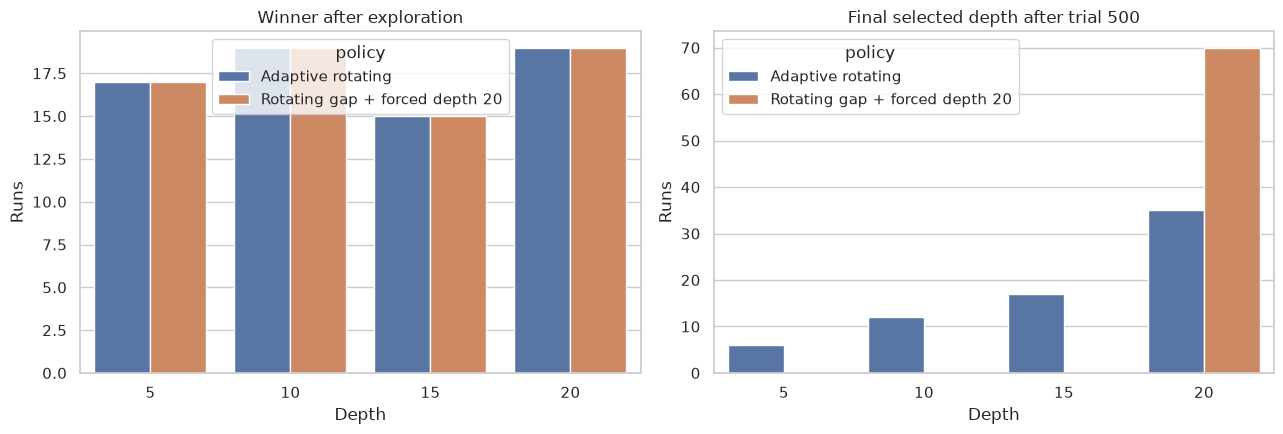

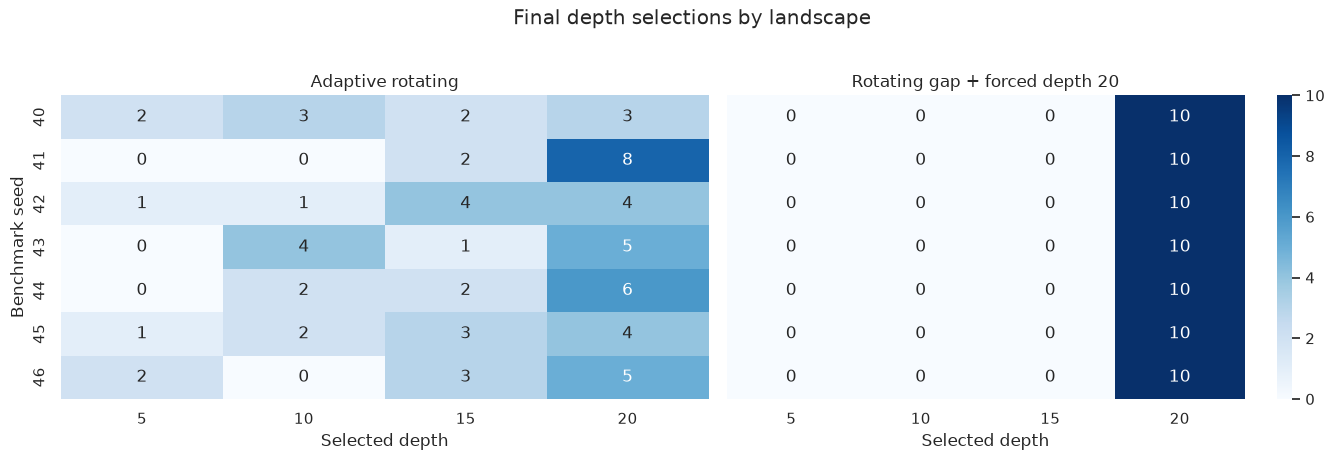

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=selections, x='first_place', order=CANDIDATE_DEPTHS, hue='policy', hue_order=ADAPTIVE_LABELS, ax=axes[0])
axes[0].set(title='Winner after exploration', xlabel='Depth', ylabel='Runs')
sns.countplot(data=selections, x='selected_depth', order=CANDIDATE_DEPTHS, hue='policy', hue_order=ADAPTIVE_LABELS, ax=axes[1])
axes[1].set(title='Final selected depth after trial 500', xlabel='Depth', ylabel='Runs')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for axis, policy in zip(axes, ADAPTIVE_LABELS):
    final_by_landscape = (pd.crosstab(
        selections.query('policy == @policy')['benchmark_seed'],
        selections.query('policy == @policy')['selected_depth'])
        .reindex(index=BENCHMARK_SEEDS, columns=CANDIDATE_DEPTHS, fill_value=0))
    sns.heatmap(final_by_landscape, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=10, cbar=policy == ADAPTIVE_LABELS[-1], ax=axis)
    axis.set_title(policy)
    axis.set_xlabel('Selected depth')
    axis.set_ylabel('Benchmark seed' if policy == ADAPTIVE_LABELS[0] else '')
fig.suptitle('Final depth selections by landscape', y=1.02)
fig.tight_layout()
plt.show()

## Overall policy ranking across benchmark seeds

Within each benchmark seed, policies are ranked by their mean final best regret across the ten SMAC seeds; lower regret is better. The overall ordering uses the average of those seven per-benchmark ranks, so every landscape receives equal weight.

In [35]:
ranking_label_order = list(ADAPTIVE_LABELS) + [f'Fixed depth {depth}' for depth in CANDIDATE_DEPTHS]
ranking_run_rows = []
for (benchmark_seed, smac_seed), data in adaptive.items():
    ranking_run_rows.append({'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed, 'label': ORIGINAL_LABEL, 'best_regret': float(data['best_regret'][-1])})
for (benchmark_seed, smac_seed), data in force20.items():
    ranking_run_rows.append({'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed, 'label': FORCE20_LABEL, 'best_regret': float(data['best_regret'][-1])})
for (depth, benchmark_seed, smac_seed), data in fixed.items():
    ranking_run_rows.append({'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed, 'label': f'Fixed depth {depth}', 'best_regret': float(data['best_regret'][-1])})
ranking_runs = pd.DataFrame(ranking_run_rows)
policy_landscape_performance = (
    ranking_runs.groupby(['benchmark_seed', 'label'], as_index=False)
    .agg(mean_final_best_regret=('best_regret', 'mean'))
)
policy_landscape_performance['landscape_rank'] = (
    policy_landscape_performance.groupby('benchmark_seed')['mean_final_best_regret']
    .rank(method='average', ascending=True)
)
rank_table = (policy_landscape_performance
    .pivot(index='label', columns='benchmark_seed', values='landscape_rank')
    .reindex(ranking_label_order))
rank_table.columns = [f'rank_benchmark_{seed}' for seed in rank_table.columns]
rank_table['average_landscape_rank'] = rank_table.mean(axis=1)
rank_table['best_landscape_rank'] = rank_table.filter(like='rank_benchmark_').min(axis=1)
rank_table['worst_landscape_rank'] = rank_table.filter(like='rank_benchmark_').max(axis=1)
rank_table['mean_of_landscape_mean_regrets'] = (
    policy_landscape_performance.groupby('label')['mean_final_best_regret'].mean()
)
rank_table = (rank_table.reset_index()
    .sort_values(['average_landscape_rank', 'mean_of_landscape_mean_regrets'])
    .reset_index(drop=True))
rank_table.insert(0, 'overall_rank', np.arange(1, len(rank_table) + 1))
display(rank_table.style.format({
    **{f'rank_benchmark_{seed}': '{:.1f}' for seed in BENCHMARK_SEEDS},
    'average_landscape_rank': '{:.2f}',
    'best_landscape_rank': '{:.1f}',
    'worst_landscape_rank': '{:.1f}',
    'mean_of_landscape_mean_regrets': '{:.6g}',
}))

,overall_rank,label,rank_benchmark_40,rank_benchmark_41,rank_benchmark_42,rank_benchmark_43,rank_benchmark_44,rank_benchmark_45,rank_benchmark_46,average_landscape_rank,best_landscape_rank,worst_landscape_rank,mean_of_landscape_mean_regrets
0,1,Rotating gap + forced depth 20,1.0,3.0,1.0,2.0,2.0,1.0,2.0,1.71,1.0,3.0,4260.25
1,2,Fixed depth 20,2.0,2.0,2.0,1.0,3.0,3.0,1.0,2.00,1.0,3.0,4420.33
2,3,Adaptive rotating,4.0,1.0,3.0,4.0,1.0,4.0,4.0,3.00,1.0,4.0,5397.21
3,4,Fixed depth 15,3.0,4.0,4.0,3.0,4.0,2.0,3.0,3.29,2.0,4.0,5042.02
4,5,Fixed depth 10,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.00,5.0,5.0,8629.58
5,6,Fixed depth 5,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.00,6.0,6.0,21934.3


## Improvement evidence used for selection

Only eligible depths are shown in each phase. The nonzero fraction makes explicit how often a trained-depth segment actually improved the incumbent.

,policy,phase,depth,runs,median_total_improvement,mean_nonzero_fraction,median_segments
0,Adaptive rotating,Exploration (to 250),5,70,27759.847310,0.101783,34.0
1,Adaptive rotating,Exploration (to 250),10,70,23451.007637,0.115782,34.0
2,Adaptive rotating,Exploration (to 250),15,70,17285.286308,0.107331,34.0
3,Adaptive rotating,Exploration (to 250),20,70,27161.947006,0.116555,33.5
4,Adaptive rotating,Top two (300–500),5,40,0.000000,0.008837,77.5
5,Adaptive rotating,Top two (300–500),10,32,4105.552512,0.034011,78.0
6,Adaptive rotating,Top two (300–500),15,26,3576.090887,0.037613,81.0
7,Adaptive rotating,Top two (300–500),20,42,6622.481213,0.049359,77.5
8,Rotating gap + forced depth 20,Exploration (to 250),5,70,27759.847310,0.101783,34.0
9,Rotating gap + forced depth 20,Exploration (to 250),10,70,23451.007637,0.115782,34.0


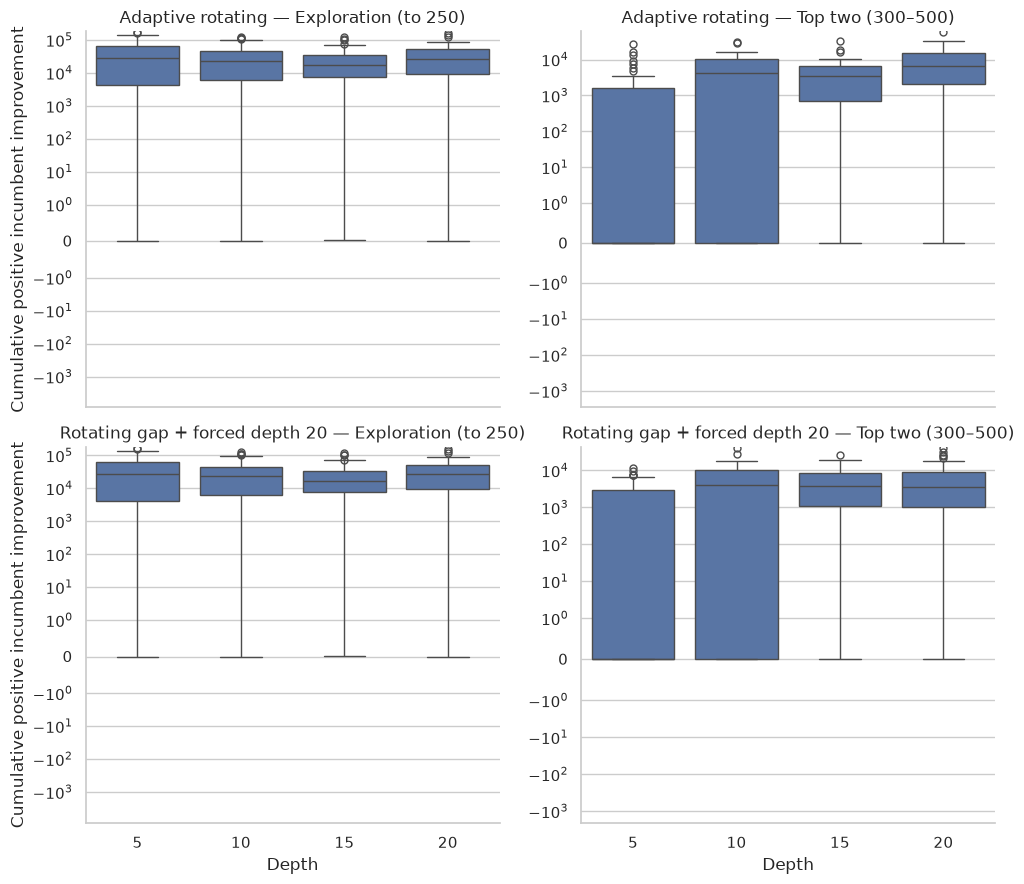

In [36]:
eligible_scores = scores.query('eligible').copy()
display(
    eligible_scores.groupby(['policy', 'phase', 'depth'])
    .agg(runs=('smac_seed', 'size'),
         median_total_improvement=('total_improvement', 'median'),
         mean_nonzero_fraction=('nonzero_fraction', 'mean'),
         median_segments=('n_segments', 'median'))
    .reset_index()
)

g = sns.catplot(
    data=eligible_scores, x='depth', y='total_improvement', col='phase', row='policy',
    kind='box', sharey=False, height=4.5, aspect=1.15,
)
g.set_axis_labels('Depth', 'Cumulative positive incumbent improvement')
g.set_titles('{row_name} — {col_name}')
for axis in g.axes.flat:
    axis.set_yscale('symlog', linthresh=1.0)
plt.show()

## Example adaptive schedules

One run from each final selected depth is shown. Vertical lines mark the end of scored exploration (250), first selection (300), and final selection (500).

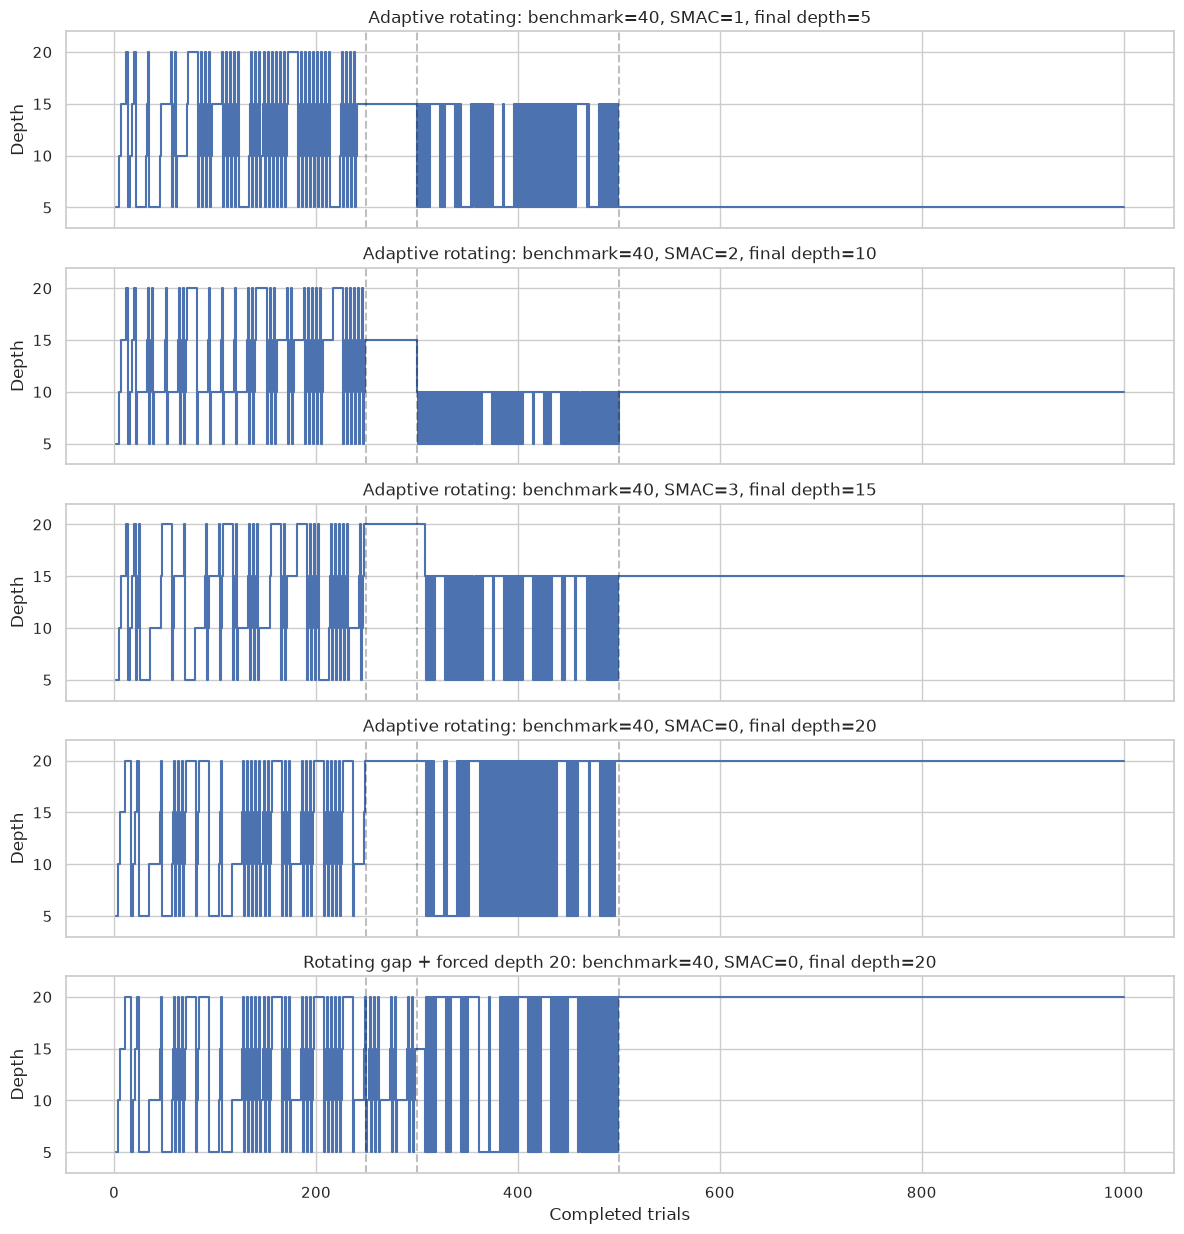

In [37]:
examples = (selections.sort_values(['policy', 'selected_depth', 'benchmark_seed', 'smac_seed'])
            .groupby(['policy', 'selected_depth'], as_index=False).first())
fig, axes = plt.subplots(len(examples), 1, figsize=(12, 2.5 * len(examples)), sharex=True)
axes = np.atleast_1d(axes)
for axis, row in zip(axes, examples.itertuples(index=False)):
    data = adaptive_collections[row.policy][(row.benchmark_seed, row.smac_seed)]
    transitions = np.asarray(data['depth_transitions'], dtype=int)
    x = np.r_[transitions[:, 0], N_TRIALS]
    y = np.r_[transitions[:, 1], transitions[-1, 1]]
    axis.step(x, y, where='post')
    for boundary in (250, 300, 500):
        axis.axvline(boundary, color='black', alpha=0.25, linestyle='--')
    axis.set(ylim=(3, 22), yticks=CANDIDATE_DEPTHS, ylabel='Depth',
             title=f'{row.policy}: benchmark={row.benchmark_seed}, SMAC={row.smac_seed}, final depth={row.selected_depth}')
axes[-1].set_xlabel('Completed trials')
plt.tight_layout()
plt.show()

## Adaptive policies versus fixed-depth controls

Curves first average the ten SMAC seeds within each landscape. The line is then the mean across seven landscapes and the band is a 95% bootstrap confidence interval across landscapes.

In [38]:
curve_frames = []
run_rows = []

def add_run(data, label, benchmark_seed, smac_seed):
    regrets = np.asarray(data['best_regret'], dtype=float)
    curve_frames.append(pd.DataFrame({
        'label': label,
        'benchmark_seed': benchmark_seed,
        'smac_seed': smac_seed,
        'iteration': np.arange(1, N_TRIALS + 1),
        'best_regret': regrets,
    }))
    for checkpoint in CHECKPOINTS:
        run_rows.append({
            'label': label,
            'benchmark_seed': benchmark_seed,
            'smac_seed': smac_seed,
            'checkpoint': checkpoint,
            'best_regret': regrets[checkpoint - 1],
        })

for (benchmark_seed, smac_seed), data in adaptive.items():
    add_run(data, ORIGINAL_LABEL, benchmark_seed, smac_seed)
for (benchmark_seed, smac_seed), data in force20.items():
    add_run(data, FORCE20_LABEL, benchmark_seed, smac_seed)
for (depth, benchmark_seed, smac_seed), data in fixed.items():
    add_run(data, f'Fixed depth {depth}', benchmark_seed, smac_seed)

curves = pd.concat(curve_frames, ignore_index=True)
checkpoints = pd.DataFrame(run_rows)
landscape_curves = (curves.groupby(['label', 'benchmark_seed', 'iteration'], as_index=False)
                    ['best_regret'].mean())
label_order = list(ADAPTIVE_LABELS) + [f'Fixed depth {depth}' for depth in CANDIDATE_DEPTHS]
palette = dict(zip(label_order, sns.color_palette('colorblind', len(label_order))))

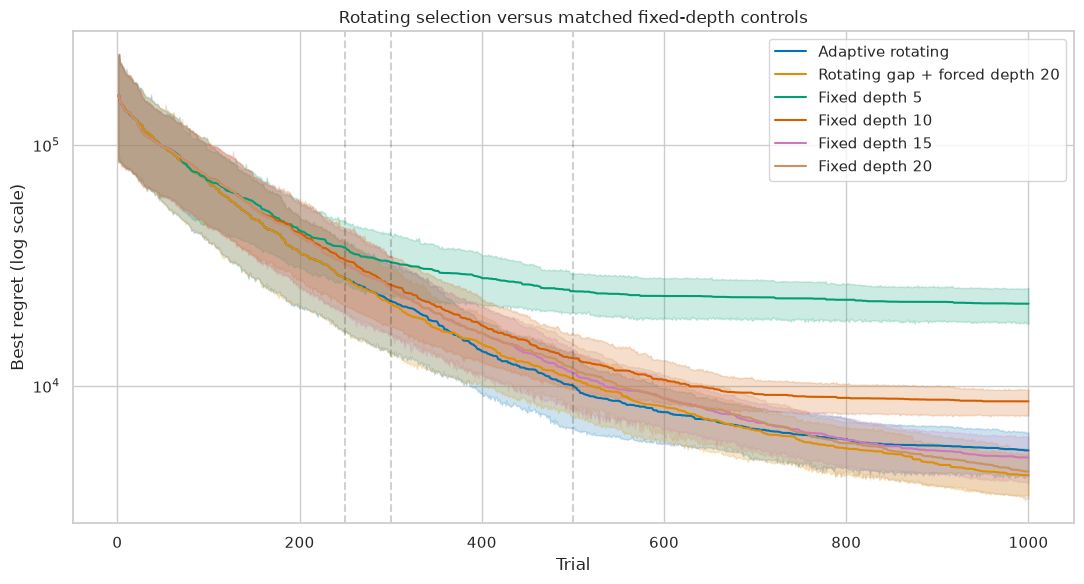

In [39]:
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=landscape_curves, x='iteration', y='best_regret', hue='label',
    hue_order=label_order, palette=palette, estimator='mean',
    errorbar=('ci', 95), n_boot=2000,
)
for boundary in (250, 300, 500):
    plt.axvline(boundary, color='black', alpha=0.18, linestyle='--')
plt.yscale('log')
plt.xlabel('Trial')
plt.ylabel('Best regret (log scale)')
plt.title('Rotating selection versus matched fixed-depth controls')
plt.legend(title=None)
plt.tight_layout()
plt.show()

## Checkpoint and paired final comparisons

Negative paired differences mean the adaptive policy achieved lower regret than the fixed control on the same landscape and SMAC seed.

mean        median  \
checkpoint label                                                        
250        Adaptive rotating               27833.905360  23168.606671   
           Rotating gap + forced depth 20  27833.905360  23168.606671   
           Fixed depth 5                   37461.777546  33503.184261   
           Fixed depth 10                  33256.035602  35137.496326   
           Fixed depth 15                  31937.225113  32237.866898   
           Fixed depth 20                  32066.379506  32237.866898   
300        Adaptive rotating               22454.260129  17985.453299   
           Rotating gap + forced depth 20  22021.351379  17373.152209   
           Fixed depth 5                   32608.865950  28916.354084   
           Fixed depth 10                  26368.691255  27056.905257   
           Fixed depth 15                  25590.010768  23029.944022   
           Fixed depth 20                  25490.546055  23003.312250   
500        Adaptive rotating                9993.211423   8901.746666   
           Rotating gap + forced depth 20  10765.057916   8748.998618   
           Fixed depth 5                   24692.379554  22360.490840   
           Fixed depth 10                  13045.729319  12749.840992   
           Fixed depth 15                  11309.266206  11524.831253   
           Fixed depth 20                  11754.286942  11002.330372   
750        Adaptive rotating                6278.188244   6296.498131   
           Rotating gap + forced depth 20   5934.744994   5316.466890   
           Fixed depth 5                   23086.983453  22360.490840   
           Fixed depth 10                   9054.016028   8697.369098   
           Fixed depth 15                   6475.369616   5828.670635   
           Fixed depth 20                   6402.584503   6163.954964   
1000       Adaptive rotating                5397.206972   4903.685176   
           Rotating gap + forced depth 20   4260.249037   4095.325777   
           Fixed depth 5                   21934.262183  21465.787058   
           Fixed depth 10                   8629.575665   8131.267352   
           Fixed depth 15                   5042.021774   4379.640298   
           Fixed depth 20                   4420.331158   4447.205642   

                                                    std  
checkpoint label                                         
250        Adaptive rotating               19908.226974  
           Rotating gap + forced depth 20  19908.226974  
           Fixed depth 5                   21576.626247  
           Fixed depth 10                  20706.746682  
           Fixed depth 15                  21733.199927  
           Fixed depth 20                  21552.200922  
300        Adaptive rotating               16134.695478  
           Rotating gap + forced depth 20  16437.821715  
           Fixed depth 5                   19279.381485  
           Fixed depth 10                  15353.322927  
           Fixed depth 15                  16058.749132  
           Fixed depth 20                  15785.959102  
500        Adaptive rotating                6151.649591  
           Rotating gap + forced depth 20   6718.778599  
           Fixed depth 5                   11147.723341  
           Fixed depth 10                   6894.301435  
           Fixed depth 15                   5644.457272  
           Fixed depth 20                   6431.012212  
750        Adaptive rotating                3472.042975  
           Rotating gap + forced depth 20   3386.396164  
           Fixed depth 5                   10026.750618  
           Fixed depth 10                   4045.420313  
           Fixed depth 15                   3265.886329  
           Fixed depth 20                   3314.649667  
1000       Adaptive rotating                3171.027900  
           Rotating gap + forced depth 20   2214.566007  
           Fixed depth 5                    8504.353194  
           Fixed depth 10       

,adaptive_policy,comparison,adaptive_win_rate,ties,mean_adaptive_minus_comparison,median_adaptive_minus_comparison
0,Adaptive rotating,Rotating gap + forced depth 20,0.414286,0,1136.957935,662.101368
1,Adaptive rotating,Fixed depth 5,0.985714,0,-16537.055211,-15687.622024
2,Adaptive rotating,Fixed depth 10,0.742857,0,-3232.368693,-3199.117553
3,Adaptive rotating,Fixed depth 15,0.485714,0,355.185198,298.028270
4,Adaptive rotating,Fixed depth 20,0.442857,0,976.875814,575.881130
5,Rotating gap + forced depth 20,Adaptive rotating,0.585714,0,-1136.957935,-662.101368
6,Rotating gap + forced depth 20,Fixed depth 5,1.000000,0,-17674.013146,-16874.288297
7,Rotating gap + forced depth 20,Fixed depth 10,0.885714,0,-4369.326628,-3705.652788
8,Rotating gap + forced depth 20,Fixed depth 15,0.614286,0,-781.772737,-672.509305
9,Rotating gap + forced depth 20,Fixed depth 20,0.528571,0,-160.082121,-78.270692


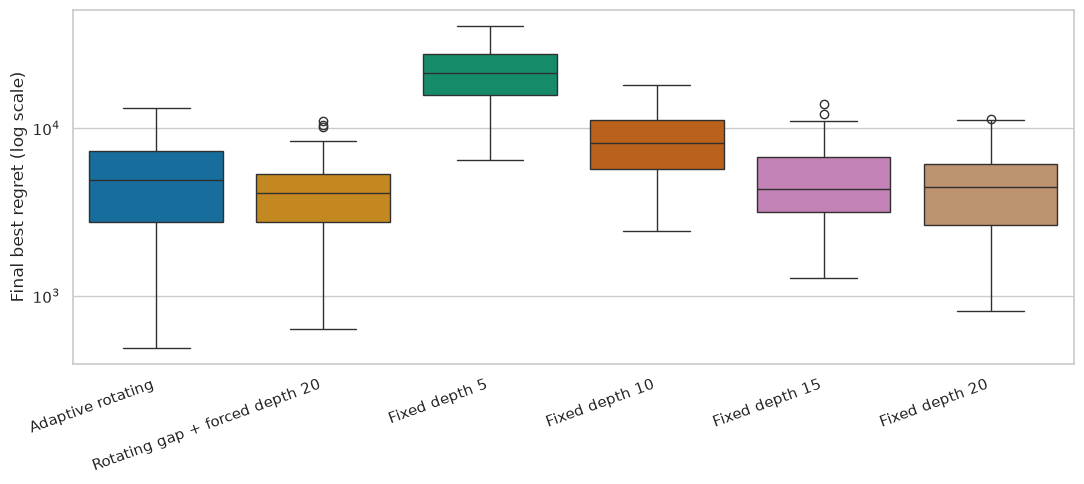

In [40]:
checkpoint_summary = (
    checkpoints.groupby(['checkpoint', 'label'])['best_regret']
    .agg(['mean', 'median', 'std'])
    .reindex(label_order, level='label')
)
display(checkpoint_summary)

final_wide = (checkpoints.query('checkpoint == 1000')
              .pivot(index=['benchmark_seed', 'smac_seed'], columns='label', values='best_regret'))
paired_rows = []
for adaptive_label in ADAPTIVE_LABELS:
    for comparison in label_order:
        if comparison == adaptive_label:
            continue
        difference = final_wide[adaptive_label] - final_wide[comparison]
        paired_rows.append({
            'adaptive_policy': adaptive_label,
            'comparison': comparison,
            'adaptive_win_rate': float((difference < 0).mean()),
            'ties': int((difference == 0).sum()),
            'mean_adaptive_minus_comparison': difference.mean(),
            'median_adaptive_minus_comparison': difference.median(),
        })
paired_summary = pd.DataFrame(paired_rows)
display(paired_summary)

final_long = checkpoints.query('checkpoint == 1000').copy()
plt.figure(figsize=(11, 5))
sns.boxplot(data=final_long, x='label', y='best_regret', order=label_order, palette=palette, hue='label', legend=False)
plt.yscale('log')
plt.xlabel('')
plt.ylabel('Final best regret (log scale)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Performance conditional on the final selected depth

This is descriptive rather than causal: the selected groups differ because the preceding optimization histories differ.

runs         mean       median  \
policy                         selected_depth                                   
Adaptive rotating              5                  6  9335.511233  8789.831837   
                               10                12  8782.703373  7723.447829   
                               15                17  4765.811062  4268.707208   
                               20                35  3868.005488  3574.228122   
Rotating gap + forced depth 20 20                70  4260.249037  4095.325777   

                                                       std  
policy                         selected_depth               
Adaptive rotating              5               2043.416624  
                               10              2450.529260  
                               15              2511.718764  
                               20              2343.493143  
Rotating gap + forced depth 20 20              2214.566007

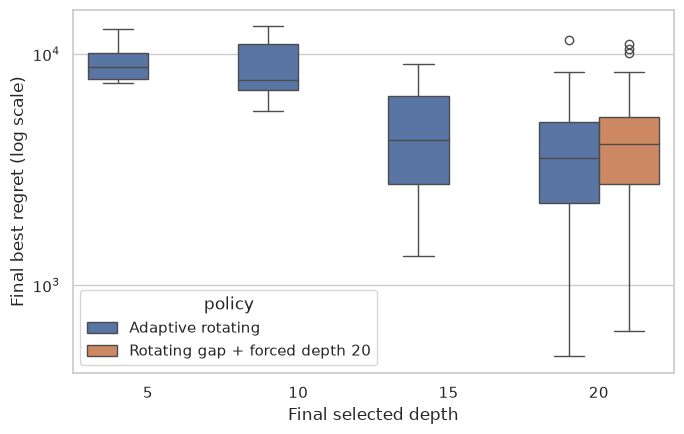

In [41]:
display(
    selections.groupby(['policy', 'selected_depth'])['final_best_regret']
    .agg(runs='size', mean='mean', median='median', std='std')
)
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=selections, x='selected_depth', y='final_best_regret', order=CANDIDATE_DEPTHS, hue='policy', hue_order=ADAPTIVE_LABELS)
plt.yscale('log')
plt.xlabel('Final selected depth')
plt.ylabel('Final best regret (log scale)')
plt.tight_layout()
plt.show()

## Per-landscape convergence with 95% confidence intervals

Each panel contains one benchmark landscape. Lines and pointwise 95% Student-t confidence intervals are calculated across its ten SMAC seeds, separately for the adaptive policy and fixed depths 5, 10, 15, and 20.

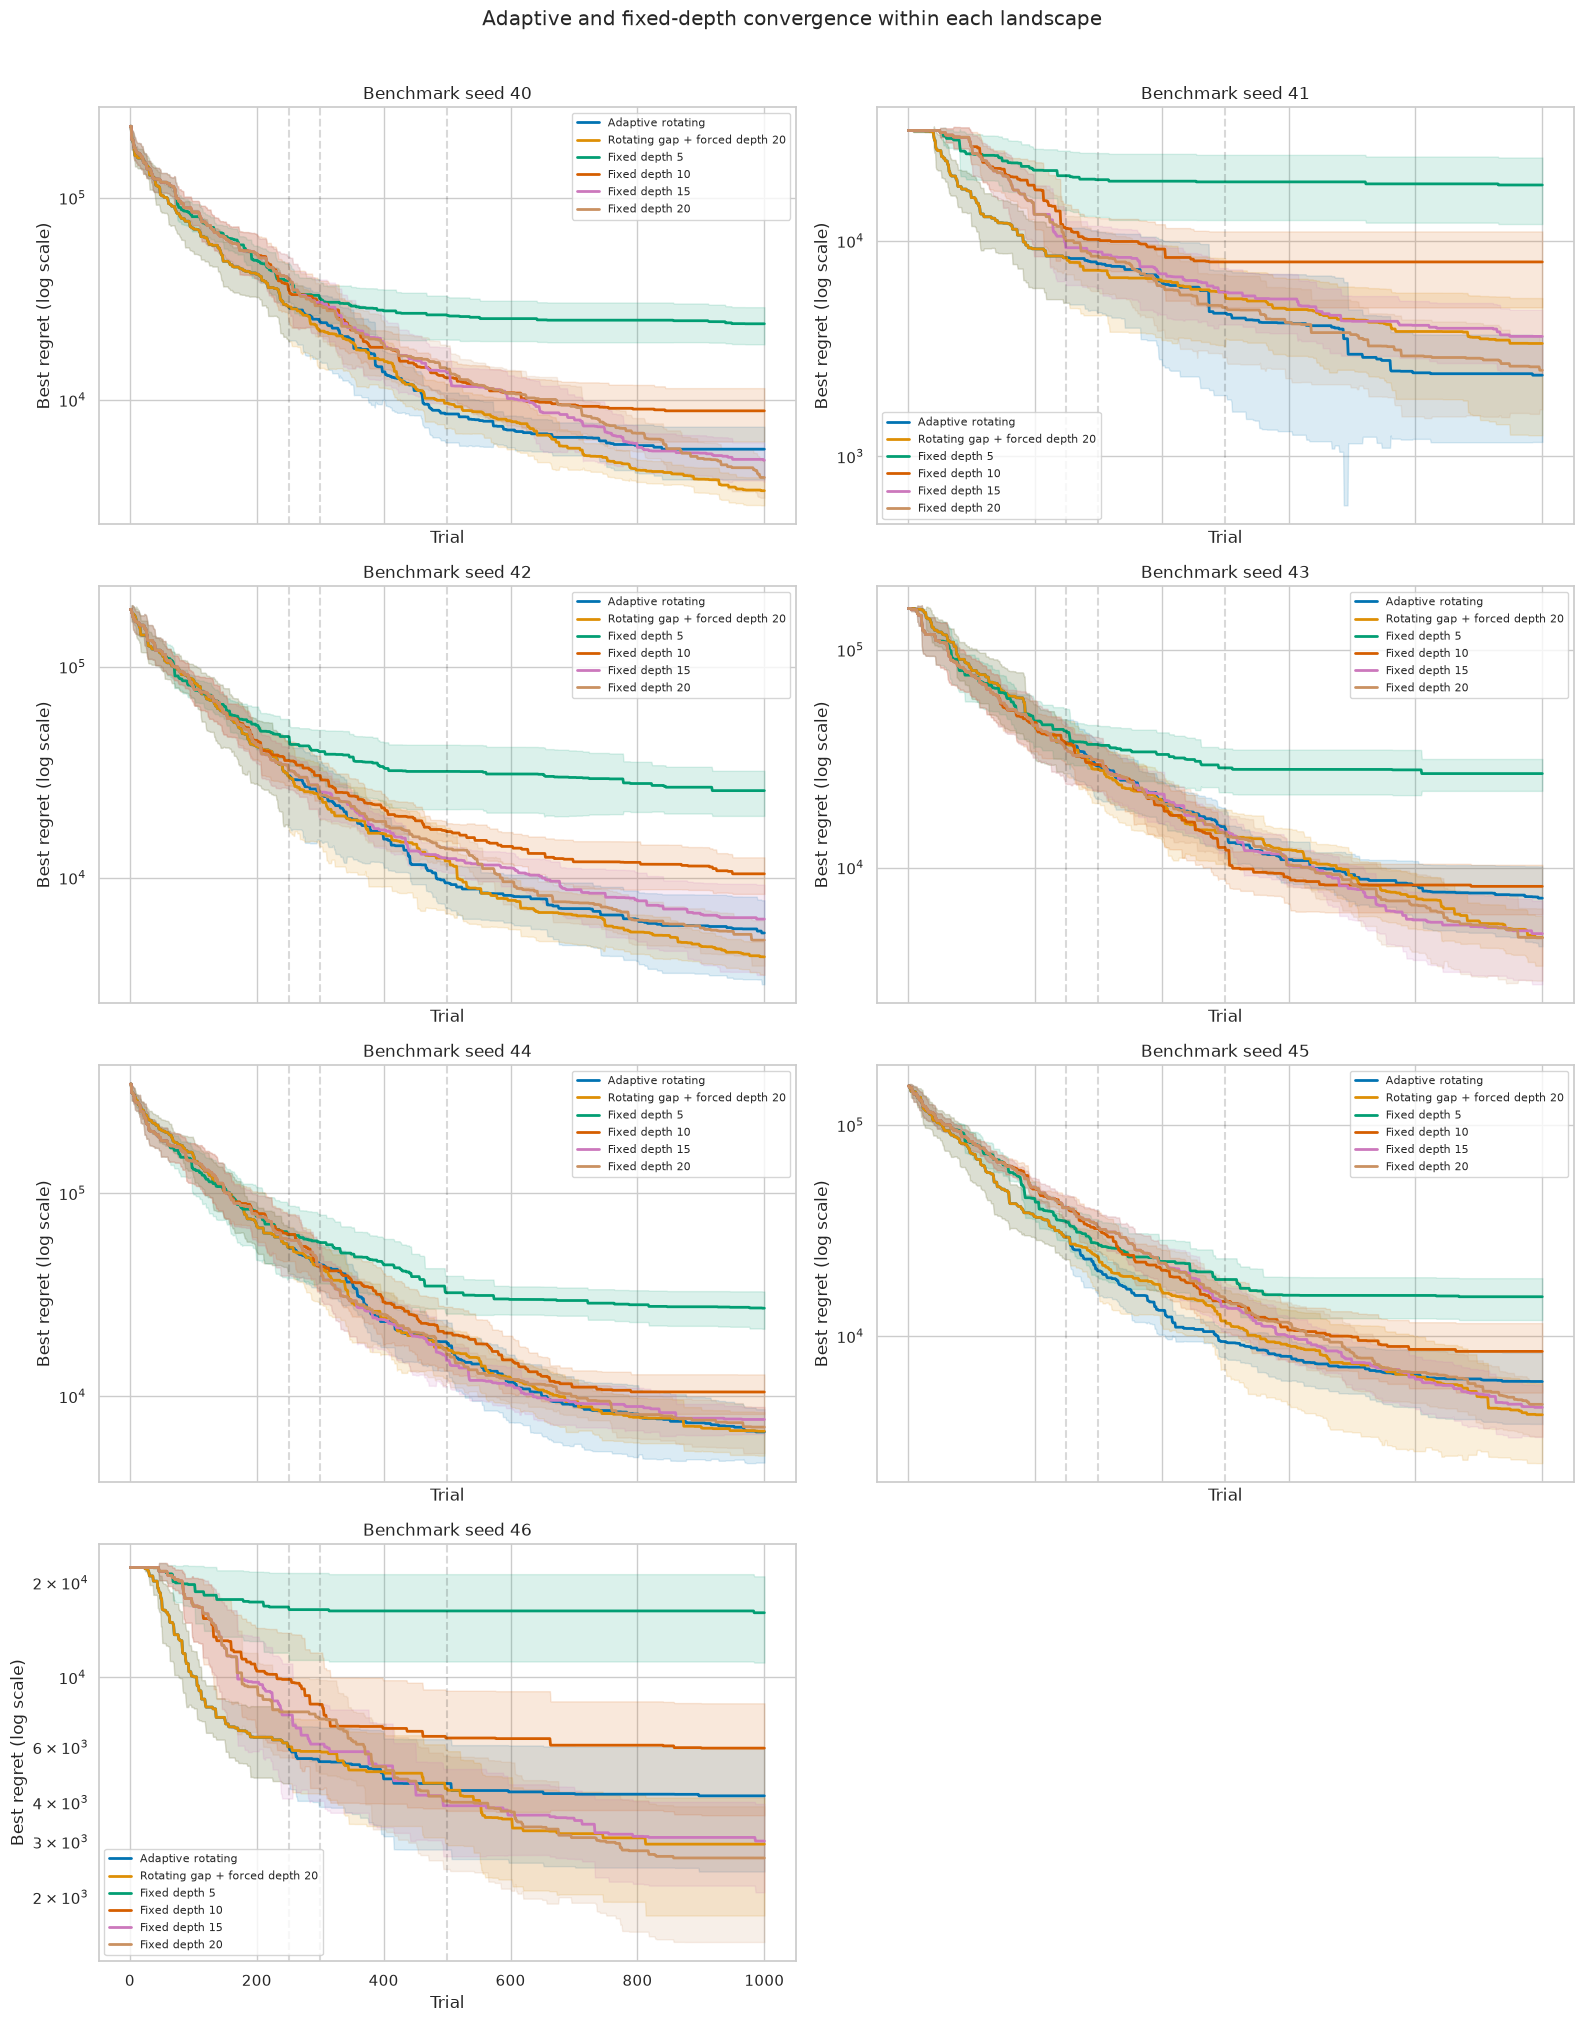

In [42]:
from scipy.stats import t

landscape_curve_summary = (
    curves.groupby(['benchmark_seed', 'label', 'iteration'])['best_regret']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
landscape_curve_summary['ci95'] = (
    t.ppf(0.975, landscape_curve_summary['count'] - 1)
    * landscape_curve_summary['std']
    / np.sqrt(landscape_curve_summary['count'])
)

fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
axes = axes.ravel()
for axis, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    subset = landscape_curve_summary.query('benchmark_seed == @benchmark_seed')
    for label in label_order:
        line = subset.query('label == @label')
        x = line['iteration'].to_numpy()
        mean = line['mean'].to_numpy()
        ci = line['ci95'].to_numpy()
        axis.plot(x, mean, label=label, color=palette[label], lw=2)
        axis.fill_between(x, np.maximum(mean - ci, 1e-300), mean + ci,
                          color=palette[label], alpha=0.14)
    for boundary in (250, 300, 500):
        axis.axvline(boundary, color='black', alpha=0.15, linestyle='--')
    axis.set_yscale('log')
    axis.set_title(f'Benchmark seed {benchmark_seed}')
    axis.set_xlabel('Trial')
    axis.set_ylabel('Best regret (log scale)')
    axis.legend(fontsize=8, title=None)
axes[-1].axis('off')
fig.suptitle('Adaptive and fixed-depth convergence within each landscape', y=1.01)
fig.tight_layout()
plt.show()

## Per-landscape regret distributions every 250 trials

Each box contains the ten SMAC-seed results for one policy at trials 250, 500, 750, or 1,000.

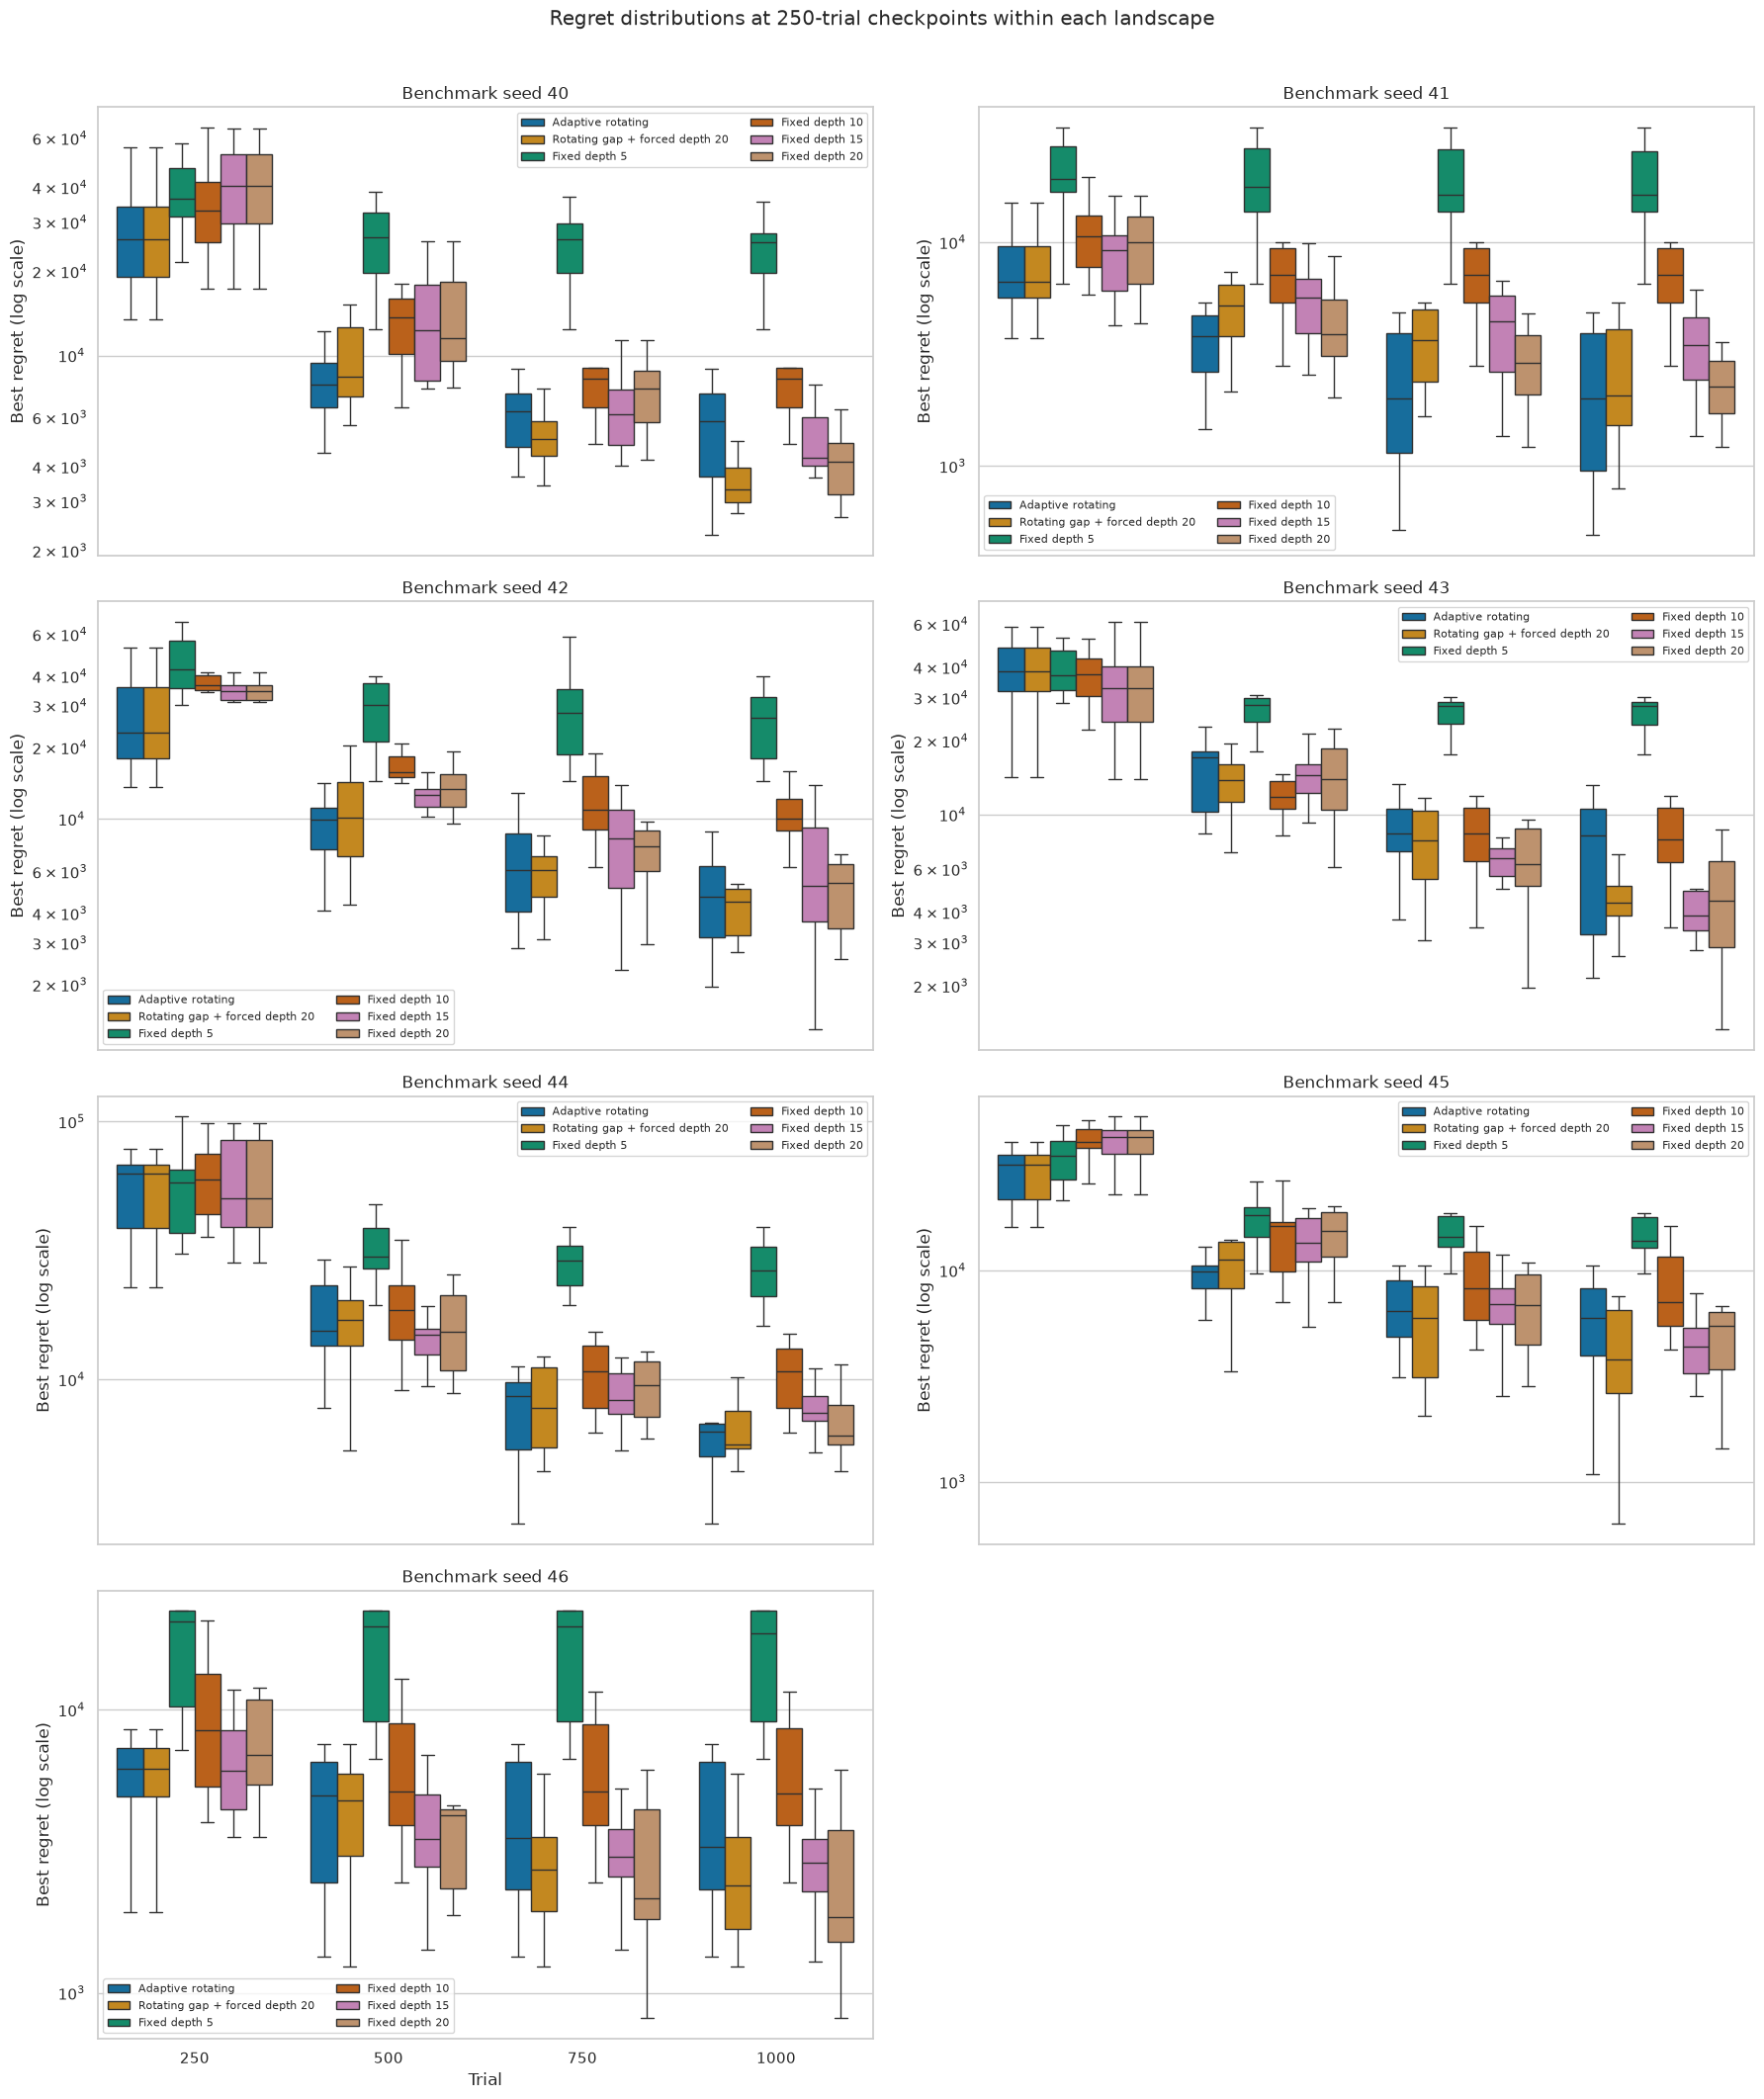

In [43]:
LANDSCAPE_CHECKPOINTS = (250, 500, 750, 1000)
landscape_checkpoint_data = checkpoints.query('checkpoint in @LANDSCAPE_CHECKPOINTS').copy()
landscape_checkpoint_data['checkpoint'] = pd.Categorical(
    landscape_checkpoint_data['checkpoint'], categories=LANDSCAPE_CHECKPOINTS, ordered=True
)

fig, axes = plt.subplots(4, 2, figsize=(18, 21), sharex=True)
axes = axes.ravel()
for axis, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    subset = landscape_checkpoint_data.query('benchmark_seed == @benchmark_seed')
    sns.boxplot(
        data=subset, x='checkpoint', y='best_regret', hue='label',
        hue_order=label_order, palette=palette, showfliers=False, ax=axis,
    )
    axis.set_yscale('log')
    axis.set_title(f'Benchmark seed {benchmark_seed}')
    axis.set_xlabel('Trial')
    axis.set_ylabel('Best regret (log scale)')
    axis.legend(fontsize=8, title=None, ncol=2)
axes[-1].axis('off')
fig.suptitle('Regret distributions at 250-trial checkpoints within each landscape', y=1.01)
fig.tight_layout()
plt.show()

## Per-landscape selection counts after both stages

For every landscape and depth, these tables count the ten SMAC runs in which that depth ranked first after stage 1, ranked first after stage 2, or was deployed after trial 500. The stage-2 winner becomes the final selected depth by construction, so the last two panels are expected to be identical.

decision                                      Final selected            \
depth                                                     5  10 15  20   
policy                         benchmark_seed                            
Adaptive rotating              40                          2  3  2   3   
                               41                          0  0  2   8   
                               42                          1  1  4   4   
                               43                          0  4  1   5   
                               44                          0  2  2   6   
                               45                          1  2  3   4   
                               46                          2  0  3   5   
Rotating gap + forced depth 20 40                          0  0  0  10   
                               41                          0  0  0  10   
                               42                          0  0  0  10   
                               43                          0  0  0  10   
                               44                          0  0  0  10   
                               45                          0  0  0  10   
                               46                          0  0  0  10   

decision                                      Stage 1 winner           \
depth                                                     5  10 15 20   
policy                         benchmark_seed                           
Adaptive rotating              40                          5  3  2  0   
                               41                          0  2  4  4   
                               42                          4  4  1  1   
                               43                          0  3  1  6   
                               44                          5  3  0  2   
                               45                          3  1  3  3   
                               46                          0  3  4  3   
Rotating gap + forced depth 20 40                          5  3  2  0   
                               41                          0  2  4  4   
                               42                          4  4  1  1   
                               43                          0  3  1  6   
                               44                          5  3  0  2   
                               45                          3  1  3  3   
                               46                          0  3  4  3   

decision                                      Stage 2 winner           
depth                                                     5  10 15 20  
policy                         benchmark_seed                          
Adaptive rotating              40                          2  3  2  3  
                               41                          0  0  2  8  
                               42                          1  1  4  4  
                               43                          0  4  1  5  
                               44                          0  2  2  6  
                               45                          1  2  3  4  
                               46                          2  0  3  5  
Rotating gap + forced depth 20 40                          0  4  2  4  
                               41                          0  0  4  6  
                               42                          1  2  5  2  
                               43                          2  4  1  3  
                               44                          1  4  1  4  
                               45                          0  2  3  5  
                               46                          1  1  3  5

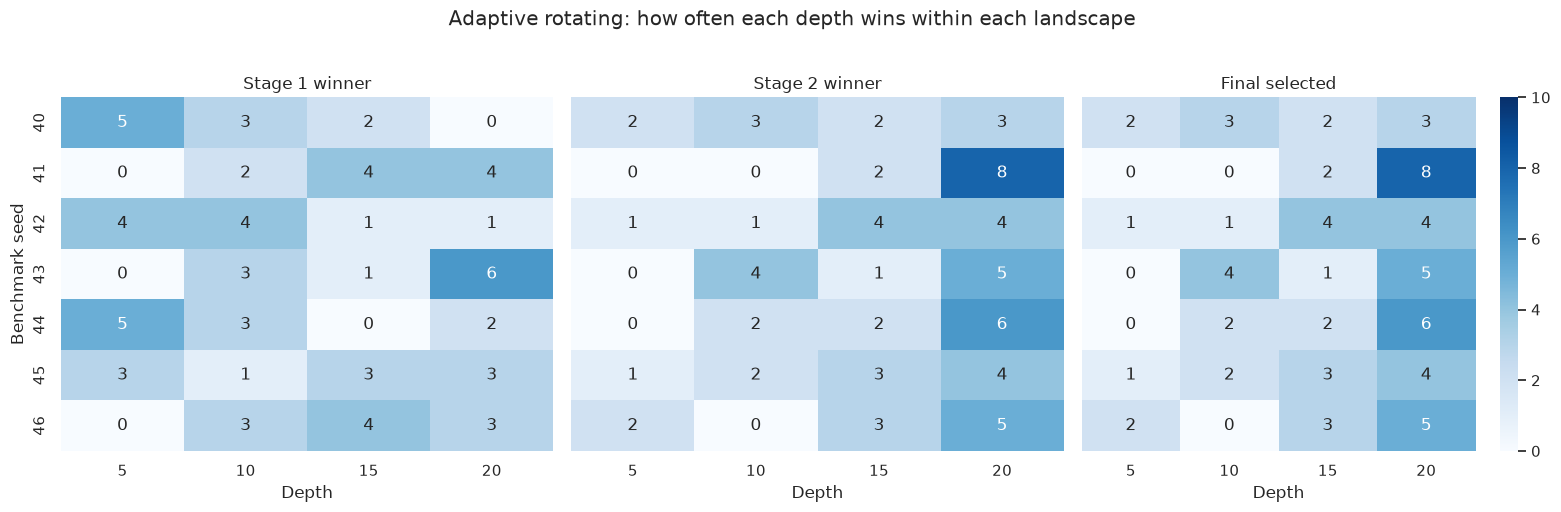

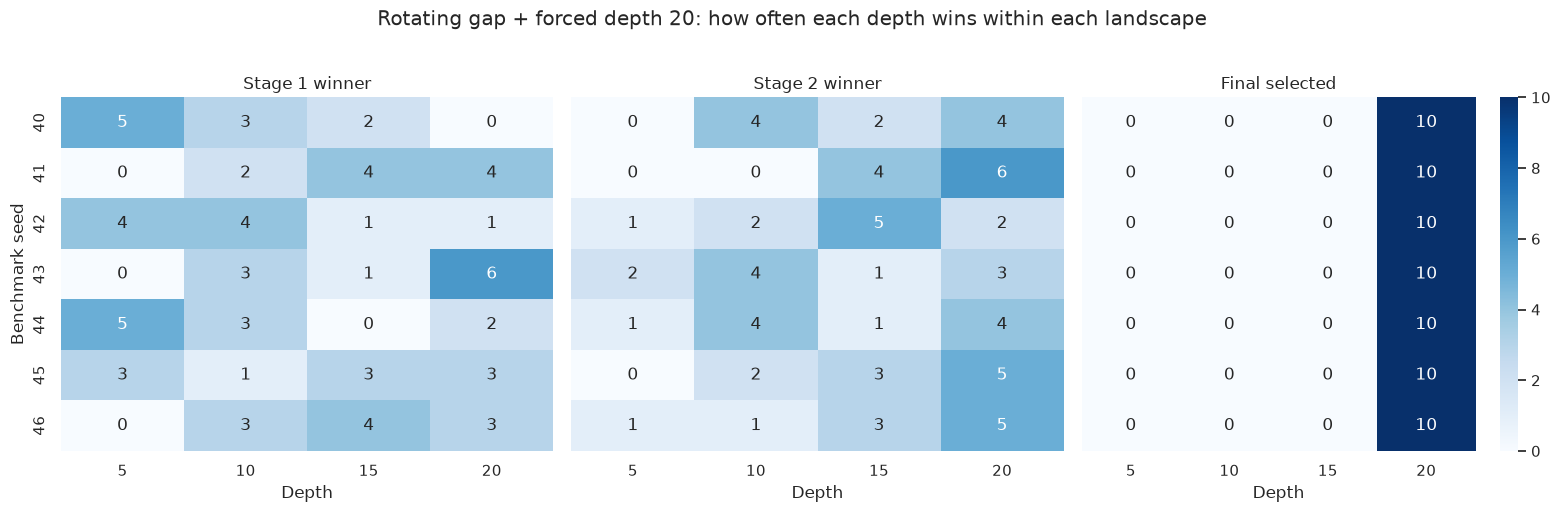

In [44]:
stage_decision_rows = []
for (benchmark_seed, smac_seed), data in adaptive.items():
    stage_decision_rows.extend([
        {'policy': ORIGINAL_LABEL, 'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed,
         'decision': 'Stage 1 winner', 'depth': data['first_ranking'][0]},
        {'policy': ORIGINAL_LABEL, 'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed,
         'decision': 'Stage 2 winner', 'depth': data['second_ranking'][0]},
        {'policy': ORIGINAL_LABEL, 'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed,
         'decision': 'Final selected', 'depth': data['selected_depth']},
    ])
for (benchmark_seed, smac_seed), data in force20.items():
    stage_decision_rows.extend([
        {'policy': FORCE20_LABEL, 'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed,
         'decision': 'Stage 1 winner', 'depth': data['first_ranking'][0]},
        {'policy': FORCE20_LABEL, 'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed,
         'decision': 'Stage 2 winner', 'depth': data['second_ranking'][0]},
        {'policy': FORCE20_LABEL, 'benchmark_seed': benchmark_seed, 'smac_seed': smac_seed,
         'decision': 'Final selected', 'depth': data['selected_depth']},
    ])
stage_decisions = pd.DataFrame(stage_decision_rows)
decision_order = ('Stage 1 winner', 'Stage 2 winner', 'Final selected')
selection_counts = (
    stage_decisions.groupby(['policy', 'decision', 'benchmark_seed', 'depth']).size()
    .reindex(
        pd.MultiIndex.from_product(
            [ADAPTIVE_LABELS, decision_order, BENCHMARK_SEEDS, CANDIDATE_DEPTHS],
            names=['policy', 'decision', 'benchmark_seed', 'depth'],
        ),
        fill_value=0,
    )
    .rename('runs')
    .reset_index()
)
selection_count_table = selection_counts.pivot_table(
    index=['policy', 'benchmark_seed'], columns=['decision', 'depth'], values='runs', fill_value=0
)
display(selection_count_table.astype(int))
for decision in decision_order:
    assert selection_count_table[decision].sum(axis=1).eq(10).all()

for policy in ADAPTIVE_LABELS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for axis, decision in zip(axes, decision_order):
        matrix = (selection_counts.query('policy == @policy and decision == @decision')
                  .pivot(index='benchmark_seed', columns='depth', values='runs')
                  .reindex(index=BENCHMARK_SEEDS, columns=CANDIDATE_DEPTHS))
        sns.heatmap(matrix, annot=True, fmt='d', vmin=0, vmax=10, cmap='Blues',
                    cbar=decision == decision_order[-1], ax=axis)
        axis.set_title(decision)
        axis.set_xlabel('Depth')
        axis.set_ylabel('Benchmark seed' if decision == decision_order[0] else '')
    fig.suptitle(f'{policy}: how often each depth wins within each landscape', y=1.02)
    fig.tight_layout()
    plt.show()

## Detailed stage evaluation for SMAC seeds 0 and 1

For two representative SMAC seeds in every landscape, the following tables expose the exact evidence used at the end of each stage: per-depth rank, cumulative and average incumbent improvement, number of surrogate-depth segments, fraction of improving segments, eligibility, advancing status, and best regret at the stage endpoint. Stage 1 ends at trial 250; stage 2 ends at trial 500.

In [45]:
DETAIL_SMAC_SEEDS = (0, 1)
stage_evaluation_rows = []
for benchmark_seed in BENCHMARK_SEEDS:
    for smac_seed in DETAIL_SMAC_SEEDS:
        data = adaptive[(benchmark_seed, smac_seed)]
        stage_definitions = [
            ('Stage 1', 250, 'exploration_scores', data['first_ranking'], set(data['selected_two'])),
            ('Stage 2', 500, 'top_two_scores', data['second_ranking'], {data['selected_depth']}),
        ]
        for stage, end_trial, score_field, ranking, advances in stage_definitions:
            rank_lookup = {depth: rank for rank, depth in enumerate(ranking, start=1)}
            for depth in CANDIDATE_DEPTHS:
                score = data[score_field][str(depth)]
                improvements = np.asarray(score['segment_improvements'], dtype=float)
                eligible = bool(score['n_segments'])
                stage_evaluation_rows.append({
                    'policy': ORIGINAL_LABEL,
                    'benchmark_seed': benchmark_seed,
                    'smac_seed': smac_seed,
                    'stage': stage,
                    'end_trial': end_trial,
                    'depth': depth,
                    'rank': rank_lookup.get(depth, np.nan),
                    'eligible': eligible,
                    'advances_or_selected': depth in advances,
                    'total_improvement': score['total_improvement'],
                    'average_improvement': score['average_improvement'],
                    'n_segments': score['n_segments'],
                    'nonzero_fraction': (np.mean(improvements > 0) if improvements.size else np.nan),
                    'best_regret_at_stage_end': data['best_regret'][end_trial - 1],
                })
for benchmark_seed in BENCHMARK_SEEDS:
    for smac_seed in DETAIL_SMAC_SEEDS:
        data = force20[(benchmark_seed, smac_seed)]
        stage_definitions = [
            ('Stage 1', 250, 'exploration_scores', data['first_ranking'], set(data['selected_two'])),
            ('Stage 2', 500, 'top_two_scores', data['second_ranking'], {data['selected_depth']}),
        ]
        for stage, end_trial, score_field, ranking, advances in stage_definitions:
            rank_lookup = {depth: rank for rank, depth in enumerate(ranking, start=1)}
            for depth in CANDIDATE_DEPTHS:
                score = data[score_field][str(depth)]
                improvements = np.asarray(score['segment_improvements'], dtype=float)
                eligible = bool(score['n_segments'])
                stage_evaluation_rows.append({
                    'policy': FORCE20_LABEL,
                    'benchmark_seed': benchmark_seed,
                    'smac_seed': smac_seed,
                    'stage': stage,
                    'end_trial': end_trial,
                    'depth': depth,
                    'rank': rank_lookup.get(depth, np.nan),
                    'eligible': eligible,
                    'advances_or_selected': depth in advances,
                    'total_improvement': score['total_improvement'],
                    'average_improvement': score['average_improvement'],
                    'n_segments': score['n_segments'],
                    'nonzero_fraction': (np.mean(improvements > 0) if improvements.size else np.nan),
                    'best_regret_at_stage_end': data['best_regret'][end_trial - 1],
                })
stage_evaluation = pd.DataFrame(stage_evaluation_rows)

for benchmark_seed in BENCHMARK_SEEDS:
    print(f'Benchmark seed {benchmark_seed}: detailed evidence for SMAC seeds {DETAIL_SMAC_SEEDS}')
    table = stage_evaluation.query('benchmark_seed == @benchmark_seed').copy()
    display(
        table.sort_values(['policy', 'smac_seed', 'stage', 'rank', 'depth'])
        .style.format({
            'rank': '{:.0f}',
            'total_improvement': '{:.5g}',
            'average_improvement': '{:.5g}',
            'nonzero_fraction': '{:.1%}',
            'best_regret_at_stage_end': '{:.5g}',
        }, na_rep='—')
    )

Benchmark seed 40: detailed evidence for SMAC seeds (0, 1)


,policy,benchmark_seed,smac_seed,stage,end_trial,depth,rank,eligible,advances_or_selected,total_improvement,average_improvement,n_segments,nonzero_fraction,best_regret_at_stage_end
0,Adaptive rotating,40,0,Stage 1,250,5,1,True,True,88415,3048.8,29,17.2%,43606
3,Adaptive rotating,40,0,Stage 1,250,20,2,True,True,39015,1345.3,29,24.1%,43606
1,Adaptive rotating,40,0,Stage 1,250,10,3,True,False,27555,950.18,29,17.2%,43606
2,Adaptive rotating,40,0,Stage 1,250,15,4,True,False,27284,940.84,29,3.4%,43606
7,Adaptive rotating,40,0,Stage 2,500,20,1,True,True,27819,415.2,67,7.5%,5455.9
4,Adaptive rotating,40,0,Stage 2,500,5,2,True,False,4782.7,71.383,67,3.0%,5455.9
5,Adaptive rotating,40,0,Stage 2,500,10,—,False,False,0,0,0,—,5455.9
6,Adaptive rotating,40,0,Stage 2,500,15,—,False,False,0,0,0,—,5455.9
8,Adaptive rotating,40,1,Stage 1,250,5,1,True,True,1.3068e+05,3532,37,13.5%,28602
10,Adaptive rotating,40,1,Stage 1,250,15,2,True,True,40873,1104.7,37,10.8%,28602


Benchmark seed 41: detailed evidence for SMAC seeds (0, 1)


,policy,benchmark_seed,smac_seed,stage,end_trial,depth,rank,eligible,advances_or_selected,total_improvement,average_improvement,n_segments,nonzero_fraction,best_regret_at_stage_end
19,Adaptive rotating,41,0,Stage 1,250,20,1,True,True,9446.7,269.9,35,14.3%,10346
17,Adaptive rotating,41,0,Stage 1,250,10,2,True,True,8268.2,236.23,35,11.4%,10346
16,Adaptive rotating,41,0,Stage 1,250,5,3,True,False,2824.6,78.462,36,8.3%,10346
18,Adaptive rotating,41,0,Stage 1,250,15,4,True,False,1711.6,48.902,35,11.4%,10346
23,Adaptive rotating,41,0,Stage 2,500,20,1,True,True,4818,54.75,88,2.3%,3997.8
21,Adaptive rotating,41,0,Stage 2,500,10,2,True,False,0,0,87,0.0%,3997.8
20,Adaptive rotating,41,0,Stage 2,500,5,—,False,False,0,0,0,—,3997.8
22,Adaptive rotating,41,0,Stage 2,500,15,—,False,False,0,0,0,—,3997.8
27,Adaptive rotating,41,1,Stage 1,250,20,1,True,True,12729,276.72,46,8.7%,5638.1
26,Adaptive rotating,41,1,Stage 1,250,15,2,True,True,7543.8,164,46,4.3%,5638.1


Benchmark seed 42: detailed evidence for SMAC seeds (0, 1)


...

,policy,benchmark_seed,smac_seed,stage,end_trial,depth,rank,eligible,advances_or_selected,total_improvement,average_improvement,n_segments,nonzero_fraction,best_regret_at_stage_end
64,Adaptive rotating,44,0,Stage 1,250,5,1,True,True,1.5927e+05,5137.9,31,16.1%,28657
65,Adaptive rotating,44,0,Stage 1,250,10,2,True,True,73333,2365.6,31,19.4%,28657
67,Adaptive rotating,44,0,Stage 1,250,20,3,True,False,62975,2099.2,30,13.3%,28657
66,Adaptive rotating,44,0,Stage 1,250,15,4,True,False,20938,697.93,30,13.3%,28657
69,Adaptive rotating,44,0,Stage 2,500,10,1,True,True,11295,150.6,75,6.7%,15796
68,Adaptive rotating,44,0,Stage 2,500,5,2,True,False,0,0,75,0.0%,15796
70,Adaptive rotating,44,0,Stage 2,500,15,—,False,False,0,0,0,—,15796
71,Adaptive rotating,44,0,Stage 2,500,20,—,False,False,0,0,0,—,15796
72,Adaptive rotating,44,1,Stage 1,250,5,1,True,True,1.4069e+05,4396.6,32,15.6%,42545
75,Adaptive rotating,44,1,Stage 1,250,20,2,True,True,67293,2102.9,32,12.5%,42545


Benchmark seed 45: detailed evidence for SMAC seeds (0, 1)


,policy,benchmark_seed,smac_seed,stage,end_trial,depth,rank,eligible,advances_or_selected,total_improvement,average_improvement,n_segments,nonzero_fraction,best_regret_at_stage_end
83,Adaptive rotating,45,0,Stage 1,250,20,1,True,True,43880,1625.2,27,14.8%,34404
80,Adaptive rotating,45,0,Stage 1,250,5,2,True,True,32770,1170.4,28,14.3%,34404
81,Adaptive rotating,45,0,Stage 1,250,10,3,True,False,29317,1047,28,25.0%,34404
82,Adaptive rotating,45,0,Stage 1,250,15,4,True,False,12940,479.26,27,14.8%,34404
87,Adaptive rotating,45,0,Stage 2,500,20,1,True,True,17415,272.11,64,10.9%,7946.7
84,Adaptive rotating,45,0,Stage 2,500,5,2,True,False,2463.2,38.487,64,1.6%,7946.7
85,Adaptive rotating,45,0,Stage 2,500,10,—,False,False,0,0,0,—,7946.7
86,Adaptive rotating,45,0,Stage 2,500,15,—,False,False,0,0,0,—,7946.7
88,Adaptive rotating,45,1,Stage 1,250,5,1,True,True,79358,2144.8,37,10.8%,19925
90,Adaptive rotating,45,1,Stage 1,250,15,2,True,True,21592,583.57,37,10.8%,19925


Benchmark seed 46: detailed evidence for SMAC seeds (0, 1)


,policy,benchmark_seed,smac_seed,stage,end_trial,depth,rank,eligible,advances_or_selected,total_improvement,average_improvement,n_segments,nonzero_fraction,best_regret_at_stage_end
98,Adaptive rotating,46,0,Stage 1,250,15,1,True,True,9482.3,215.51,44,13.6%,4388.4
96,Adaptive rotating,46,0,Stage 1,250,5,2,True,True,4538.2,103.14,44,4.5%,4388.4
97,Adaptive rotating,46,0,Stage 1,250,10,3,True,False,3799,86.342,44,6.8%,4388.4
99,Adaptive rotating,46,0,Stage 1,250,20,4,True,False,153.99,3.4998,44,4.5%,4388.4
102,Adaptive rotating,46,0,Stage 2,500,15,1,True,True,2244.8,24.668,91,2.2%,1338.9
100,Adaptive rotating,46,0,Stage 2,500,5,2,True,False,0,0,91,0.0%,1338.9
101,Adaptive rotating,46,0,Stage 2,500,10,—,False,False,0,0,0,—,1338.9
103,Adaptive rotating,46,0,Stage 2,500,20,—,False,False,0,0,0,—,1338.9
105,Adaptive rotating,46,1,Stage 1,250,10,1,True,True,8336,163.45,51,5.9%,8538.7
104,Adaptive rotating,46,1,Stage 1,250,5,2,True,True,5146.1,100.9,51,2.0%,8538.7
